# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [3]:
# 1. Business Understanding & Objective: Understand what features influence used car prices and provide recommendations to dealerships.
"""
Identify and Quantify the impact of key features—such as vehicle age, mileage, brand, fuel type, and condition—on price. 
The objective is to build and evaluate predictive models that can estimate used car prices and uncover which attributes most influence consumer valuation.

"""

'\nIdentify and Quantify the impact of key features—such as vehicle age, mileage, brand, fuel type, and condition—on price. \nThe objective is to build and evaluate predictive models that can estimate used car prices and uncover which attributes most influence consumer valuation.\n\n'

In [5]:
# 2. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import root_mean_squared_error, r2_score

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [6]:
# 3. Load Data
df = pd.read_csv("data/vehicles.csv")
df.head()
#Total number of NaN values in the entire DataFrame:
print(f"Total number of Nan values in Dataframe: {df.isna().sum().sum()}")
print(f"Total number of Nan values per Columns: {df.isna().sum()}")
print(f"Total number of Nan values per Row: {df.isna().sum(axis=1)}")
print(f"Number of columns: {df.shape[1]}")

Total number of Nan values in Dataframe: 1215152
Total number of Nan values per Columns: id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64
Total number of Nan values per Row: 0         14
1         14
2         14
3         14
4         14
          ..
426875     2
426876     2
426877     3
426878     1
426879     3
Length: 426880, dtype: int64
Number of columns: 18


In [9]:
#Data Details
"""
Total number of Nan values in Dataframe: 1215152
Total number of Nan values per Columns:
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64
Total number of Nan values per Row: 0         14
1         14
2         14
3         14
4         14
          ..
426875     2
426876     2
426877     3
426878     1
426879     3
Length: 426880, dtype: int64
Number of columns: 18

"""

'\nTotal number of Nan values in Dataframe: 1215152\nTotal number of Nan values per Columns:\nregion               0\nprice                0\nyear              1205\nmanufacturer     17646\nmodel             5277\ncondition       174104\ncylinders       177678\nfuel              3013\nodometer          4400\ntitle_status      8242\ntransmission      2556\nVIN             161042\ndrive           130567\nsize            306361\ntype             92858\npaint_color     130203\nstate                0\ndtype: int64\nTotal number of Nan values per Row: 0         14\n1         14\n2         14\n3         14\n4         14\n          ..\n426875     2\n426876     2\n426877     3\n426878     1\n426879     3\nLength: 426880, dtype: int64\nNumber of columns: 18\n\n'

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [11]:
# 4. Data Cleaning & Preprocessing
#High number of NaN values for following columns in the Dataset
#condition: 174104, #cylinders:177678, #VIN:161042, #drive:130567, #size:306361, #paint_color:130203, #type:92858

# Drop high-missing or irrelevant columns

cols_to_drop = ['VIN', 'size', 'cylinders', 'condition', 'drive', 'paint_color', 'type']
df.drop(columns=cols_to_drop, inplace=True)
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")


Number of rows: 426880
Number of columns: 11


In [13]:
# Drop rows with essential missing values
required_cols = ['year', 'odometer', 'manufacturer', 'model', 'fuel', 'transmission', 'title_status']
df.dropna(subset=required_cols, inplace=True)
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 389604
Number of columns: 11


In [15]:
# Filter outliers
df = df[(df['price'] > 100) & (df['price'] < 100000)]
df = df[df['odometer'] < 300000]
df.reset_index(drop=True, inplace=True)

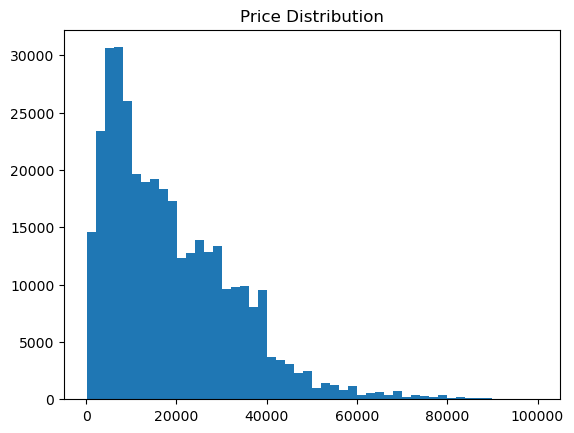

In [17]:
# 5. EDA
# Histograms and boxplots
plt.hist(df['price'], bins=50)
plt.title("Price Distribution")
plt.savefig("./images/EDA_Plot.png")  # Save as PNG to images folder
plt.show()

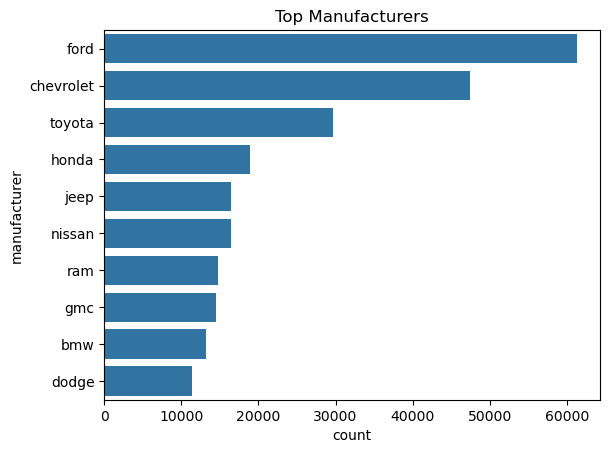

In [19]:
# Top manufacturers
sns.countplot(y=df['manufacturer'], order=df['manufacturer'].value_counts().index[:10])
plt.title("Top Manufacturers")
plt.savefig("./images/Top_Manufacturer_Plot.png") # Save as PNG to images folder
plt.show()

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [24]:
# 6. Feature Engineering
X = df.drop(columns=['price', 'id', 'region'])
y = df['price']

categorical = ['manufacturer', 'model', 'fuel', 'title_status', 'transmission', 'state']
numeric = ['year', 'odometer']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', StandardScaler(), numeric)
])


In [23]:
# 7. Modeling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ridge Regression with GridSearch
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

param_grid = {'model__alpha': [0.1, 1.0, 10.0]}
ridge_grid = GridSearchCV(ridge_pipe, param_grid, cv=5, scoring='neg_root_mean_squared_error')
ridge_grid.fit(X_train, y_train)

# Linear Regression
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
lr_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['manufacturer', 'model',
                                                   'fuel', 'title_status',
                                                   'transmission', 'state']),
                                                 ('num', StandardScaler(),
                                                  ['year', 'odometer'])])),
                ('model', LinearRegression())])

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [ ]:
# 8. Evaluation
y_pred_ridge = ridge_grid.predict(X_test)
y_pred_lr = lr_pipe.predict(X_test)

#print("Ridge Test RMSE:", mean_squared_error(y_test, y_pred_ridge, squared=False))
#print("Ridge R²:", r2_score(y_test, y_pred_ridge))
#print("Linear Test RMSE:", mean_squared_error(y_test, y_pred_lr, squared=False))
#print("Linear R²:", r2_score(y_test, y_pred_lr))



print("Ridge Test RMSE:", root_mean_squared_error(y_test, y_pred_ridge))
print("Ridge R Square:", r2_score(y_test, y_pred_ridge))
print("Linear Test RMSE:", root_mean_squared_error(y_test, y_pred_lr))
print("Linear R Square:", r2_score(y_test, y_pred_lr))

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [ ]:
# 9. Conclusion
"""
- Newer cars and low mileage significantly increase value
- Automatics and gas-powered cars dominate
- Ridge regression performs slightly better than basic linear regression
"""
# Deploy as a pricing recommendation dashboard